In [ ]:
# import Pkg
# Pkg.develop(path=pwd())

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [2]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using Statistics
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#15 (generic function with 1 method)

In [3]:
discount_factor=0.99
period = 1
graph=RVSDDP.InfiniteLinearGraph(period);

In [5]:
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    N=1
    @variable(subproblem, 0 <= volume[1:N] <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation[1:4] >= 0
        thermal_generation_tot >= 0
        hydro_generation[1:N] >= 0
        hydro_spill[1:N] >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 80.0]
    # Ω = [40.0]
    P = [1 / length(Ω) for _ in Ω]
    # Ω = [70.0]
    # P = [1.0]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    capa_th = [10 15 10 5] 
    c_th = [1 2 5 10]
    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            [i in 1:N], volume[i].out == volume[i].in - hydro_generation[i] - hydro_spill[i] + inflow
            [i in 1:N], hydro_generation[i] <= 100
            [i in 1:1], thermal_generation[i] <= capa_th[i]
            thermal_generation_tot==sum(thermal_generation[i] for i in 1:4)
            deficit + sum(hydro_generation[i] for i in 1:N) + thermal_generation_tot == 60
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 1*(50*sum(hydro_spill[i] for i in 1:N) + 50 * deficit+ sum(thermal_generation[i]*c_th[i] for i in 1:4)))
    return subproblem
end

subproblem_builder (generic function with 1 method)

In [17]:
graph = RVSDDP.LinearGraph(120);
model0 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model0; refine_mode = 0, parallel=parallel, cut_limit = 100, infinite = false, shift_function=RVSDDP.no_shift);

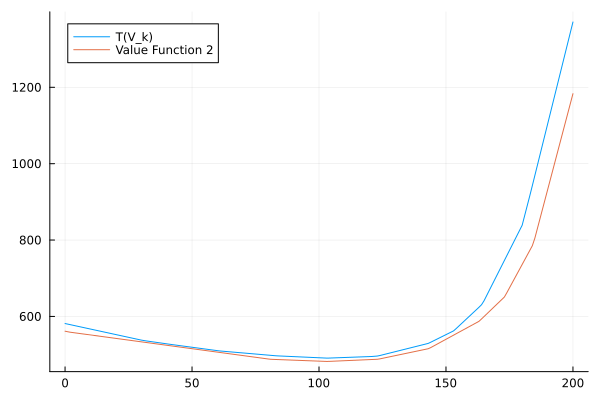

In [20]:
node=model0.nodes[1]
ind=0:1:200
TV=[RVSDDP.compute_TV(node, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
TV_k=[RVSDDP.compute_approx_TV(node.value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
V=[RVSDDP.compute_V(node.value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
p=plot(ind, TV, label="T(V_k)")
plot!(ind, V, label="Value Function 2")
# println((TV[151]-V[151], TV[30]-V[30]))
# plot(ind, TV-V)

In [7]:
h=36
12*ceil(h/12), h/12

(36.0, 3.0)

In [19]:
graph=RVSDDP.InfiniteLinearGraph(period);
model0 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model0; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), cut_limit = 100, infinite = true, shift_function=RVSDDP.no_shift); 

In [27]:
nb_cuts_list = [10, 40, 100, 200, 500]
V = Dict()
ind = 0:1:200
discount_factor=0.9
for cut_max in nb_cuts_list
    graph=RVSDDP.InfiniteLinearGraph(period);
    model0 = RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    )

    Random.seed!(1)
    parallel= 1
    Cuts0=RVSDDP.train(model0; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), cut_limit = cut_max, infinite = true, shift_function=RVSDDP.no_shift); 
    V[cut_max]=[RVSDDP.compute_V(model0[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
end

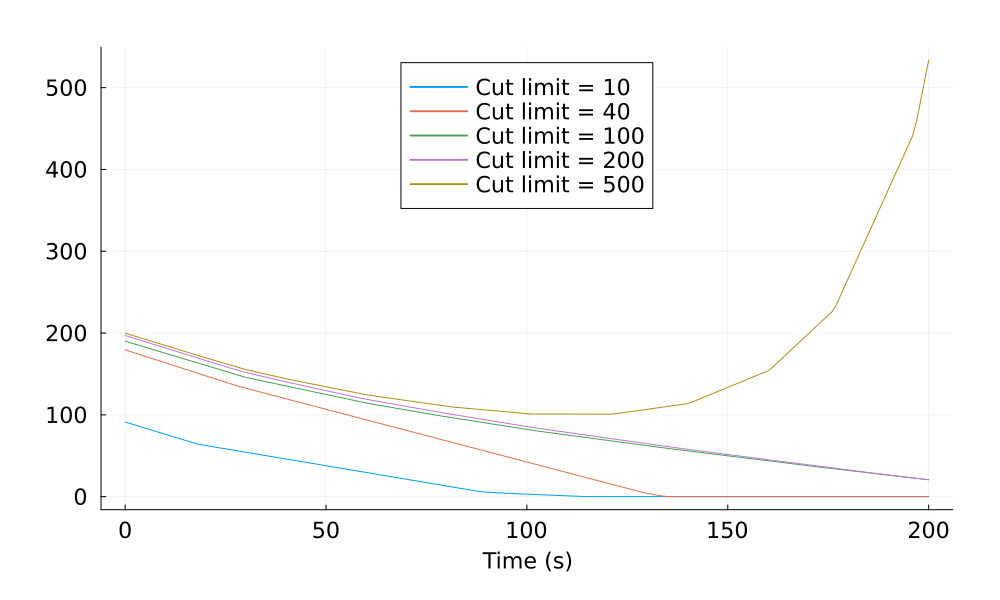

In [28]:
fontsize=15
p=plot(xlabel="Time (s)", guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, size=(1000, 600), margin=10Plots.mm, legend=:top)
for cut_max in nb_cuts_list
    plot!(ind, V[cut_max], label="Cut limit = $cut_max")
end
p

In [12]:
model0[1].value_function.cut_V
# println(model0[1].value_function.model)
# println(model0.nodes[1].subproblem)


16-element Vector{RVSDDP.Cut2}:
 RVSDDP.Cut2(0, 0.0, 0.0, Dict(Symbol("volume[1]") => 0.0), [(0.0, 1)], V ≥ 0, V_1 ≥ 0, Dict(Symbol("volume[1]") => 0.0))
 RVSDDP.Cut2(1, 0.015156030654907227, 20.0, Dict(Symbol("volume[1]") => -0.5), [(0.0, 2)], V + 0.5 volume[1]_out ≥ 20, 0.5 volume[1]_out + V_1 ≥ 20, Dict(Symbol("volume[1]") => 30.0))
 RVSDDP.Cut2(1, 0.016546010971069336, 49.85, Dict(Symbol("volume[1]") => -1.2475), [(0.0, 3)], V + 1.2475 volume[1]_out ≥ 49.85, 1.2475 volume[1]_out + V_1 ≥ 49.85, Dict(Symbol("volume[1]") => 10.0))
 RVSDDP.Cut2(1, 0.017646074295043945, 48.201125, Dict(Symbol("volume[1]") => -0.6175125), [(0.0, 4)], V + 0.6175125 volume[1]_out ≥ 48.201125, 0.6175125 volume[1]_out + V_1 ≥ 48.201125, Dict(Symbol("volume[1]") => 50.0))
 RVSDDP.Cut2(2, 0.020240068435668945, 77.421933125, Dict(Symbol("volume[1]") => -1.3056686874999999), [(0.0, 5)], V + 1.3056686874999999 volume[1]_out ≥ 77.421933125, 1.3056686874999999 volume[1]_out + V_1 ≥ 77.421933125, Dict(Symbol("volume

In [49]:
discount_factor=0.999
period = 1
# graph=RVSDDP.InfiniteLinearGraph(period);
graph = RVSDDP.LinearGraph(120);

model0 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel=1
Cuts0=RVSDDP.train(model0; refine_mode=0,parallel=parallel, time_limit = 5, infinite = false, shift_function=RVSDDP.no_shift); 

In [ ]:
discount_factor=0.999
period = 1
# graph=RVSDDP.InfiniteLinearGraph(period);
graph = RVSDDP.LinearGraph(120);

model1 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel=1
Cuts1=RVSDDP.train(model1; refine_mode=0,parallel=parallel, time_limit = 10, infinite = false, shift_function=RVSDDP.shift_update_random_forward); 

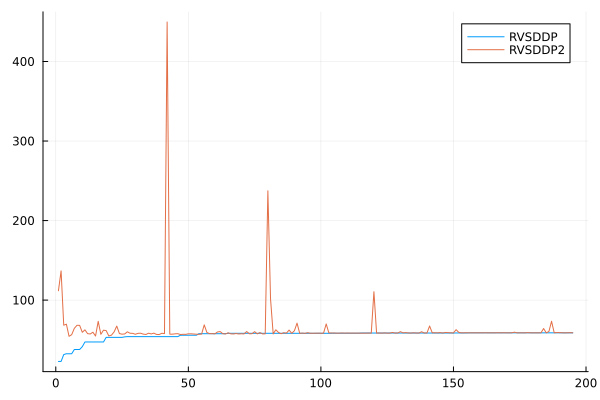

In [64]:
iter_max = length(model1.approx_value)
iter_list = 1:iter_max
p=plot(model1.approx_value .+ RVSDDP.compute_hat_delta_finite([model1[t].delta[end] for t in 1:length(model1.nodes)], discount_factor), label="RVSDDP")
# plot!(model0.approx_value[iter_list], label="Periodic SDDP")
plot!([model1.approx_value[iter] + RVSDDP.compute_hat_delta_finite([model1[t].delta[iter] for t in 1:length(model1.nodes)], discount_factor) for iter in iter_list], label="RVSDDP2")

In [54]:
Random.seed!(12345)
N=1000
TimeHorizon = 120
simulations= RVSDDP.simulate(
           model0,
           N;
           sampling_scheme = RVSDDP.InSampleMonteCarlo(max_depth=TimeHorizon),
       )
oos = [sum((discount_factor^(t-1))*simulations[k][t][:stage_objective] for t in 1:TimeHorizon) for k in 1:N];

In [53]:
mean(oos), 1.96*std(oos)/sqrt(N)

(2055.6502534164224, 81.7816273068642)

In [55]:
mean(oos), 1.96*std(oos)/sqrt(N)

(2020.5865095534764, 79.67293786128934)

In [14]:
using Statistics
using Distributions

function ic95(L::Vector{Float64})
    n = length(L)
    m = mean(L)
    s = std(L)                  # écart-type échantillon
    tcrit = quantile(TDist(n-1), 0.975)
    println((tcrit, s, sqrt(n)))
    marge = tcrit * s / sqrt(n)
    println(marge)
    return (m - marge, m, m + marge)
end

ic_oos = ic95(oos)
ic_oos, model0.approx_value[end]

(1.9611514201705804, 33.42509432053341, 44.721359549995796)
1.4657799283308206


((30.918836907512453, 32.384616835843275, 33.85039676417409), 32.862776632729165)

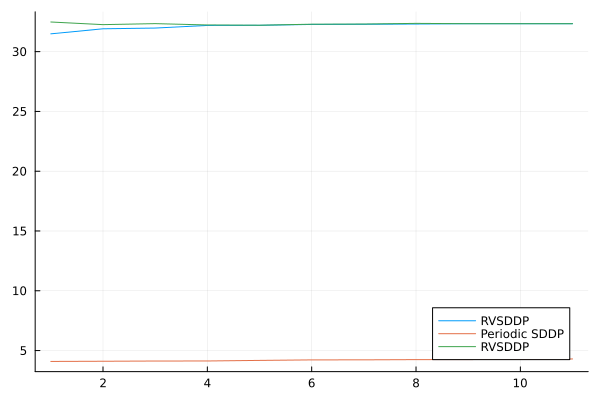

In [58]:
iter_max = 20
iter_list = 10:iter_max
p=plot(model1.approx_value[iter_list] .+ RVSDDP.compute_hat_delta([model1[t].delta for t in 1:period], period, 1, iter_max, discount_factor), label="RVSDDP")
plot!(model0b.approx_value[iter_list], label="Periodic SDDP")
plot!(model1.approx_value[iter_list] + [RVSDDP.compute_hat_delta([model1[t].delta for t in 1:period], period, 1, iter, discount_factor) for iter in iter_list], label="RVSDDP")

# plot!(model0.approx_value + [RVSDDP.compute_hat_delta([node.delta for (_, node) in model0.nodes], 1, 1, iter, 0.99) for iter in 1:100], label="RVSDDP")
# ic_oos = ic95(oos)
# hline!(p, [ic_oos[2]], label="OOS 95% CI lower", linestyle=:dash, color=:red, linewidth=2)

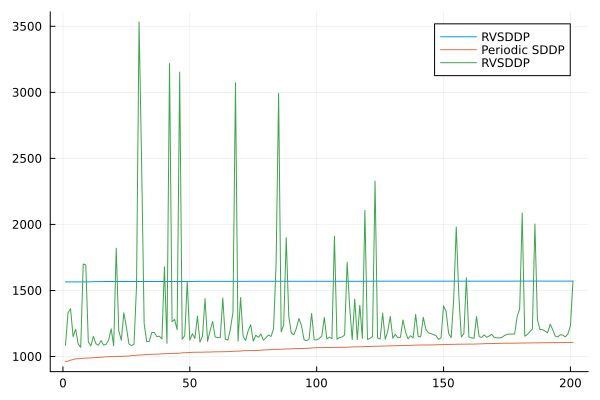

In [248]:
iter_max = 300
iter_list = 100:iter_max
p=plot(model1b.approx_value[iter_list] .+ RVSDDP.compute_hat_delta([model1b[t].delta for t in 1:120], 1, iter_max, discount_factor; period=120, infinite=false), label="RVSDDP")
plot!(model0b.approx_value[iter_list], label="Periodic SDDP")
plot!(model1b.approx_value[iter_list] + [RVSDDP.compute_hat_delta([model1b[t].delta for t in 1:120], 1, iter, discount_factor; period=120, infinite=false) for iter in iter_list], label="RVSDDP")

In [195]:
model0b.approx_value
# RVSDDP.compute_hat_delta([model1b[t].delta for t in 1:20], 20, 1, iter_max, discount_factor)

1000-element Vector{Float64}:
 17.078292508965056
 22.82390616230232
 28.542524372254277
 28.770607490152564
 28.85526646921167
 30.293143853462144
 30.3591877980077
 31.39460490287758
 31.48970171102244
 31.677795228233993
  ⋮
 32.83136069131058
 32.83162194832181
 32.83162194832181
 32.83163437213161
 32.83164679594141
 32.83164679594141
 32.83165064350824
 32.83165374946069
 32.83166070297998

In [177]:
model1b[5].value_function.cut_V[183].shift

4-element Vector{Tuple{Float64, Int64}}:
 (22.591869078644358, 183)
 (0.32526021184743215, 184)
 (0.32471412515934617, 186)
 (0.32471412515933196, 191)

In [335]:
plot(model1[1].delta)
model1[1].value_function.cut_V[2*219].shift

2-element Vector{Tuple{Float64, Int64}}:
 (16.135187970830373, 438)
 (13.110951628905042, 439)

In [280]:
model1[2].delta[228]
model1[2].value_function.cut_V[2*228].shift

10-element Vector{Tuple{Float64, Int64}}:
 (60.1274304628845, 456)
 (60.127430462884476, 457)
 (60.1274304616105, 461)
 (60.12743046148792, 462)
 (60.12743046033653, 463)
 (60.127430459185135, 469)
 (60.12743045803374, 471)
 (60.12743043607583, 472)
 (60.127430434924435, 477)
 (60.12743041296652, 478)

[[6339.702116285681, 3706.0310498957965, 3491.7293162526576, 3560.388099908435, 3499.693196228685, 3499.70439683278, 3489.146094591979, 3491.432734222844, 3492.609960219434, 3492.2834149498576], [14382.381470265718, 4100.438486464681, 3550.7971771074094, 3559.8938740531653, 3556.9556710826782, 3488.0354851476836, 3511.40570351165, 3491.8255583484543, 3491.674735340006, 3491.921564973292]]
[[4481.419135900443, 3509.7218498398393, 3502.9843683428944, 3488.366392938289, 3489.340386334879, 3488.03546856911, 3487.94712805865, 3488.167956886713, 3487.9322100086783, 3487.949667049497], [6398.409055571889, 3502.6390103108224, 3490.142618349413, 3489.630729835273, 3488.0144437329627, 3488.3451388435774, 3488.2000155461847, 3488.049306754402, 3488.0068957079334, 3487.943270082753]]


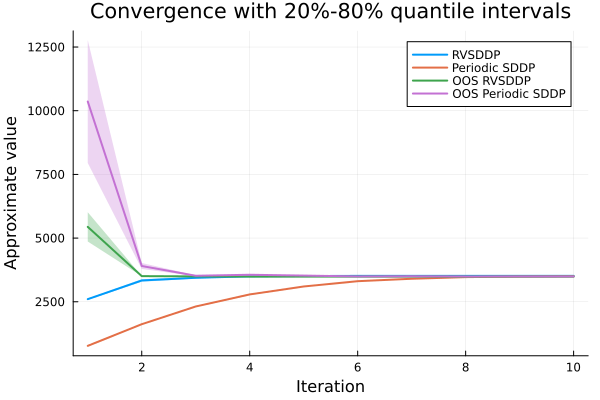

In [15]:
using CSV
using DataFrames
using Statistics

results = Dict()
seed_list = 1:2
iter_max = 100
iter_list = 10:10:100
shift_list = [RVSDDP.no_shift, RVSDDP.shift_update_random_forward]
discount_factor=0.995
period = 1
TimeHorizon = Int(round(log(0.001)/log(discount_factor)))
for seed in seed_list
    for shift in shift_list
        folder = "results_toy/$(shift)/$(discount_factor)/seed_$(seed)_iter_$(iter_max)" 
        df_approx_values = CSV.read(joinpath(folder, "approx_values.csv"), DataFrame)
        approx_values = df_approx_values[1:end, :approx_value]
        df_deltas = CSV.read(joinpath(folder, "deltas.csv"), DataFrame)
        deltas = df_deltas[1:end, :delta]
        hat_delta = [RVSDDP.compute_hat_delta([deltas], period, 1, iter, discount_factor) for iter in 1:iter_max]
        oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_horizon_$(iter)_$(TimeHorizon).csv"), DataFrame) for iter in iter_list]
        oos = [mean(oos_df[i][1:end, :oos_horizon]) for i in 1:length(oos_df)]
        results[(seed, shift)] = (approx_values, hat_delta, oos)
        # results[(seed, shift)] = (approx_values, hat_delta)
    end
end

results_mean = Dict()
for shift in shift_list
    all_approx_values = [results[(seed, shift)][1][iter_list] for seed in seed_list]
    all_hat_delta = [results[(seed, shift)][2][iter_list] for seed in seed_list]
    all_oos = [results[(seed, shift)][3] for seed in seed_list]

    println(all_oos)

    
    # Stack them into matrices for quantile computation
    approx_values_matrix = hcat(all_approx_values...)  # 100 x 10 matrix
    hat_delta_matrix = hcat(all_hat_delta...)  # 100 x 10 matrix
    oos_matrix = hcat(all_oos...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    
    # Compute quantiles (20%-80%) across seeds for each iteration
    approx_values_20 = [quantile(approx_values_matrix[iter, :], 0.2) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_80 = [quantile(approx_values_matrix[iter, :], 0.8) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_mean = mean(approx_values_matrix, dims=2)[:]
    
    hat_delta_20 = [quantile(hat_delta_matrix[iter, :], 0.2) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_80 = [quantile(hat_delta_matrix[iter, :], 0.8) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_mean = mean(hat_delta_matrix, dims=2)[:]

    oos_20 = [quantile(oos_matrix[iter, :], 0.2) for iter in 1:size(oos_matrix, 1)]
    oos_80 = [quantile(oos_matrix[iter, :], 0.8) for iter in 1:size(oos_matrix, 1)]
    oos_mean = mean(oos_matrix, dims=2)[:]

    results_mean[shift] = (approx_values_20, approx_values_80, hat_delta_20, hat_delta_80, approx_values_mean, hat_delta_mean, oos_20, oos_80, oos_mean)
end

# Plot with 20%-80% intervals as ribbons
rvsddp_value = results_mean[RVSDDP.shift_update_random_forward][5] + results_mean[RVSDDP.shift_update_random_forward][6]
rvsddp_lower = results_mean[RVSDDP.shift_update_random_forward][1] + results_mean[RVSDDP.shift_update_random_forward][3]
rvsddp_upper = results_mean[RVSDDP.shift_update_random_forward][2] + results_mean[RVSDDP.shift_update_random_forward][4]

periodic_value = results_mean[RVSDDP.no_shift][5]
periodic_lower = results_mean[RVSDDP.no_shift][1]
periodic_upper = results_mean[RVSDDP.no_shift][2]

oos_rvsddp_value = results_mean[RVSDDP.shift_update_random_forward][9]
oos_rvsddp_lower = results_mean[RVSDDP.shift_update_random_forward][7]
oos_rvsddp_upper = results_mean[RVSDDP.shift_update_random_forward][8]

oos_periodic_value = results_mean[RVSDDP.no_shift][9]
oos_periodic_lower = results_mean[RVSDDP.no_shift][7]
oos_periodic_upper = results_mean[RVSDDP.no_shift][8]

p = plot(rvsddp_value,
         ribbon=(rvsddp_value - rvsddp_lower, rvsddp_upper - rvsddp_value),
         label="RVSDDP", linewidth=2, fillalpha=0.3)
plot!(periodic_value,
      ribbon=(periodic_value - periodic_lower, periodic_upper - periodic_value),
      label="Periodic SDDP", linewidth=2, fillalpha=0.3)
plot!(oos_rvsddp_value,
      ribbon=(oos_rvsddp_value - oos_rvsddp_lower, oos_rvsddp_upper - oos_rvsddp_value),
      label="OOS RVSDDP", linewidth=2, fillalpha=0.3)
plot!(oos_periodic_value,
      ribbon=(oos_periodic_value - oos_periodic_lower, oos_periodic_upper - oos_periodic_value),
      label="OOS Periodic SDDP", linewidth=2, fillalpha=0.3)
xlabel!("Iteration")
ylabel!("Approximate value")
title!("Convergence with 20%-80% quantile intervals")
p


In [ ]:
oos_rvsddp_value[end], rvsddp_value[end], rvsddp_value[end]*discount_factor

(3487.946468566125, 3517.821566463322, 3482.731296337851)